# QSVT Compatibility Failure Cases

This tutorial shows why not every useful-looking polynomial is directly compatible with QSVT synthesis.

Goals:

- inspect parity and boundedness requirements
- compare compatible and incompatible polynomial examples
- separate QSVT-style polynomial intuition from direct QSVT synthesis claims
- read compatibility reports without overinterpreting them

The examples use sampled boundedness checks and PennyLane synthesis is disabled so the reasons are deterministic and fast to inspect.

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np

from qsvt.compatibility import qsvt_compatibility_report
from qsvt.polynomials import eval_polynomial, polynomial_parity

np.set_printoptions(precision=4, suppress=True)

## Candidate Polynomials

QSVT polynomials need compatible parity and bounded response on the signal domain. The table below includes a good even polynomial, a good odd polynomial, a mixed-parity polynomial, an out-of-bounds polynomial, and a bounded mixed-parity polynomial.

In [2]:
candidates = {
    "compatible_even_x_squared": np.array([0.0, 0.0, 1.0]),
    "compatible_odd_half_x": np.array([0.0, 0.5]),
    "mixed_parity_one_plus_x": np.array([1.0, 1.0]),
    "out_of_bounds_two_x": np.array([0.0, 2.0]),
    "bounded_mixed_offset_slope": np.array([0.25, 0.25]),
}

reports = {
    name: qsvt_compatibility_report(coeffs, attempt_synthesis=False)
    for name, coeffs in candidates.items()
}

print("candidate                         degree  parity  bounded  compatible  reasons")
print("-" * 88)
for name, report in reports.items():
    print(
        f"{name:<32}"
        f"{report['polynomial_degree']:<8}"
        f"{report['parity']:<8}"
        f"{str(report['is_bounded']):<9}"
        f"{str(report['compatible']):<12}"
        f"{', '.join(report['reasons']) or 'none'}"
    )

candidate                         degree  parity  bounded  compatible  reasons
----------------------------------------------------------------------------------------
compatible_even_x_squared       2       even    True     True        none
compatible_odd_half_x           1       odd     True     True        none
mixed_parity_one_plus_x         1       mixed   False    False       mixed_parity, out_of_bounds
out_of_bounds_two_x             1       odd     False    False       out_of_bounds
bounded_mixed_offset_slope      1       mixed   True     False       mixed_parity


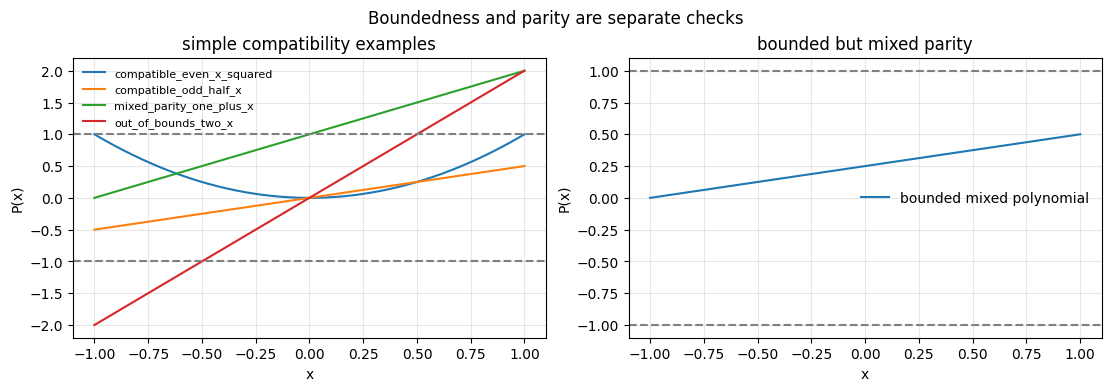

In [3]:
xs = np.linspace(-1.0, 1.0, 1001)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True)

for name in [
    "compatible_even_x_squared",
    "compatible_odd_half_x",
    "mixed_parity_one_plus_x",
    "out_of_bounds_two_x",
]:
    axes[0].plot(xs, eval_polynomial(candidates[name], xs), label=name)
axes[0].axhline(1.0, color="0.5", linestyle="--")
axes[0].axhline(-1.0, color="0.5", linestyle="--")
axes[0].set_xlabel("x")
axes[0].set_ylabel("P(x)")
axes[0].set_title("simple compatibility examples")
axes[0].legend(fontsize=8, frameon=False)
axes[0].grid(alpha=0.3)

axes[1].plot(
    xs,
    eval_polynomial(candidates["bounded_mixed_offset_slope"], xs),
    label="bounded mixed polynomial",
)
axes[1].axhline(1.0, color="0.5", linestyle="--")
axes[1].axhline(-1.0, color="0.5", linestyle="--")
axes[1].set_xlabel("x")
axes[1].set_ylabel("P(x)")
axes[1].set_title("bounded but mixed parity")
axes[1].legend(frameon=False)
axes[1].grid(alpha=0.3)

fig.suptitle("Boundedness and parity are separate checks")
plt.show()

## Why The Failure Reasons Matter

A bounded mixed-parity polynomial can still be useful for dense classical spectral experiments. It should not be described as directly synthesizable by the same QSVT path without additional construction details. Conversely, a definite-parity polynomial can fail boundedness if it leaves the allowed range.

In [4]:
diagnostic_rows = []
for name, coeffs in candidates.items():
    values = eval_polynomial(coeffs, xs)
    diagnostic_rows.append(
        {
            "name": name,
            "max_abs_value": float(np.max(np.abs(values))),
            "parity": polynomial_parity(coeffs),
            "compatible": reports[name]["compatible"],
            "reasons": reports[name]["reasons"],
        }
    )

for row in diagnostic_rows:
    print(
        f"{row['name']}: max_abs={row['max_abs_value']:.3f}, "
        f"parity={row['parity']}, compatible={row['compatible']}, "
        f"reasons={row['reasons']}"
    )

compatible_even_x_squared: max_abs=1.000, parity=even, compatible=True, reasons=[]
compatible_odd_half_x: max_abs=0.500, parity=odd, compatible=True, reasons=[]
mixed_parity_one_plus_x: max_abs=2.000, parity=mixed, compatible=False, reasons=['mixed_parity', 'out_of_bounds']
out_of_bounds_two_x: max_abs=2.000, parity=odd, compatible=False, reasons=['out_of_bounds']
bounded_mixed_offset_slope: max_abs=0.500, parity=mixed, compatible=False, reasons=['mixed_parity']


## Validation

These checks pin down the intended examples: one compatible even polynomial, one compatible odd polynomial, one mixed-parity failure, and one boundedness failure.

In [5]:
assert reports["compatible_even_x_squared"]["compatible"] is True
assert reports["compatible_odd_half_x"]["compatible"] is True
assert "mixed_parity" in reports["mixed_parity_one_plus_x"]["reasons"]
assert "out_of_bounds" in reports["out_of_bounds_two_x"]["reasons"]
assert reports["bounded_mixed_offset_slope"]["is_bounded"] is True
assert reports["bounded_mixed_offset_slope"]["has_definite_parity"] is False

print("validation: passed")

validation: passed
